In [3]:
if(!require(remotes)) install.packages("remotes")
if(!requireNamespace("datacooks", quietly = TRUE)) {
  remotes::install_github("agronomy4future/datacooks", force= TRUE)
}
library(remotes)
library(datacooks)

In [6]:
if(!require(readr)) install.packages("readr")
library(readr)

github= paste0("https://raw.githubusercontent.com/agronomy4future/",
                "raw_data_practice/refs/heads/main/",
                "fruit_size.csv")
df= data.frame(read_csv(url(github),show_col_types = FALSE))

In [7]:
set.seed(100)
print(df[sample(nrow(df),5),])

    treatment block weight_g length_cm diameter_mm area_cm2
102         B   III     39.4       9.0          30    58.35
112         B   III     78.9      10.0          44    72.23
151         B    II     57.5      10.5          50   110.89
4           A     I     28.9       8.0          34    42.67
55          A     I     92.2      10.5          65    93.56


In [8]:
model= lm(area_cm2 ~ weight_g, data= df)
summary (model)


Call:
lm(formula = area_cm2 ~ weight_g, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-46.066  -5.894  -2.390   2.197  69.957 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 18.01093    2.14532   8.395 2.73e-14 ***
weight_g     0.98325    0.04071  24.152  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 14.57 on 155 degrees of freedom
Multiple R-squared:  0.7901,	Adjusted R-squared:  0.7887 
F-statistic: 583.3 on 1 and 155 DF,  p-value: < 2.2e-16


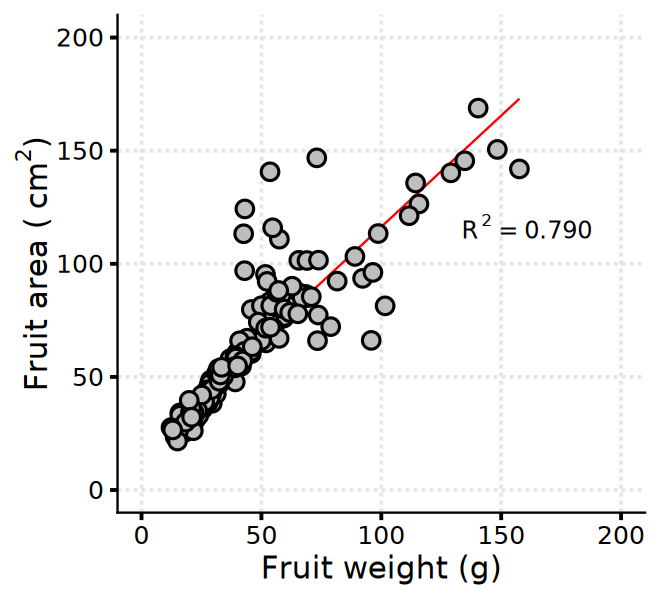

In [11]:
if(!require(ggplot2)) install.packages("ggplot2")
if(!require(ggpmisc)) install.packages("ggpmisc")
library(ggplot2)
library(ggpmisc)

Fig1= ggplot (df, aes(x=weight_g, y=area_cm2)) +
  geom_smooth(method=lm, level=0.95, se=FALSE, linetype=1, 
  linewidth=0.5, color="red", formula=y~x) +
  geom_point(stroke=1, size=4, fill="grey", shape=21) +
  # R-squared
  stat_poly_eq(aes(label=paste(..rr.label.., sep= "~~~")),
               label.x=0.9, label.y=0.6, rr.digits=3,
               formula=y ~ x, parse=TRUE, size=5) +
  scale_x_continuous(breaks = seq(0,200,50), limits = c(0,200)) +
  scale_y_continuous(breaks = seq(0,200,50), limits = c(0,200)) +
  labs(x="Fruit weight (g)", y=bquote("Fruit area ("~cm^2*")")) +
  theme_classic(base_size=18, base_family="sans")+
  theme(legend.position=c(0.89,0.13),
        legend.title=element_text(size=11),
        legend.key.size=unit(0.2,'cm'),
        legend.key=element_rect(color=alpha("white",.05), 
        fill=alpha("white",.05)),
        legend.text=element_text(size=11),
        legend.background= element_rect(fill=alpha("white",.05)),
        panel.grid.major= element_line(color="grey90", linetype="dashed"),
        axis.line=element_line(linewidth=0.5, colour="black"))

options(repr.plot.width=5.5, repr.plot.height=5)
print(Fig1)

ggsave("Fig1.png", plot= Fig1, width=5.5, height= 5, dpi= 300)

In [12]:
df1= datacooks(model, threshold= 4, clean= FALSE)

In [13]:
set.seed(100)
print(df1[sample(nrow(df1),5),])

    treatment block weight_g length_cm diameter_mm area_cm2 prediction
102         B   III     39.4       9.0          30    58.35   56.75088
112         B   III     78.9      10.0          44    72.23   95.58915
151         B    II     57.5      10.5          50   110.89   74.54765
4           A     I     28.9       8.0          34    42.67   46.42678
55          A     I     92.2      10.5          65    93.56  108.66634
      residual    leverage        ISR       CooksD category
102   1.599123 0.006556083  0.1101403 4.002795e-05   normal
112 -23.359147 0.015726165 -1.6163482 2.087117e-02   normal
151  36.342346 0.007732711  2.5045778 2.444231e-02   normal
4    -3.756780 0.008219032 -0.2589666 2.778833e-04   normal
55  -15.106337 0.024298731 -1.0498727 1.372492e-02   normal


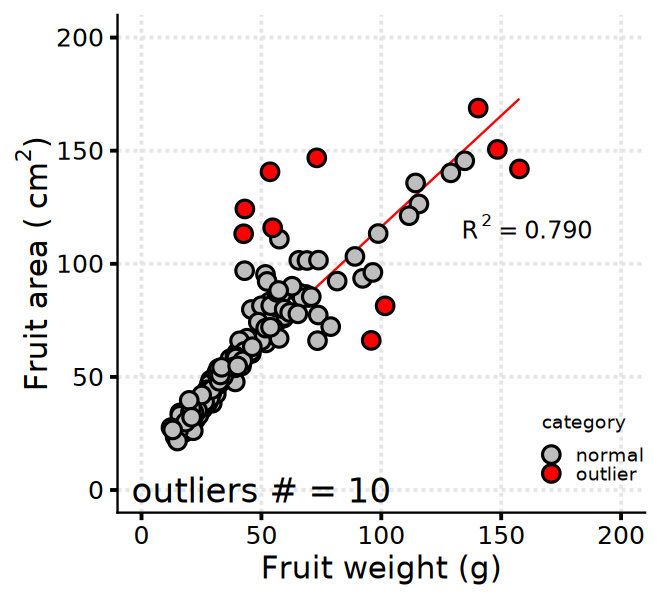

In [26]:
if(!require(ggplot2)) install.packages("ggplot2")
if(!require(ggpmisc)) install.packages("ggpmisc")
library(ggplot2)
library(ggpmisc)

Fig2= ggplot(df1, aes(x=weight_g, y=area_cm2)) +
  geom_smooth(method=lm, level=0.95, se=FALSE, 
  linetype=1, linewidth=0.5, color="red", formula=y~x) +
  geom_point(aes(fill=category, shape=category), 
  stroke=1, size=4) +
  # R-squared
  stat_poly_eq(aes(label=paste(..rr.label.., sep= "~~~")),
               label.x=0.9, label.y=0.6, rr.digits=3,
               formula=y ~ x, parse=TRUE, size=5) +

  scale_fill_manual(values= c ("grey","red")) + 
  scale_shape_manual(values= c (21,21)) +

  annotate("text", label=paste("outliers # =", 
  sum(df1$category=="outlier")),
  x=50, y=0, size=7, color="black") +

  scale_x_continuous(breaks = seq(0,200,50), limits = c(0,200)) +
  scale_y_continuous(breaks = seq(0,200,50), limits = c(0,200)) +
  labs(x="Fruit weight (g)", y=bquote("Fruit area ("~cm^2*")")) +
  theme_classic(base_size=18, base_family="sans")+
  theme(legend.position=c(0.89,0.13),
        legend.title=element_text(size=11),
        legend.key.size=unit(0.2,'cm'),
        legend.key=element_rect(color=alpha("white",.05), 
        fill=alpha("white",.05)),
        legend.text=element_text(size=11),
        legend.background= element_rect(fill=alpha("white",.05)),
        panel.grid.major= element_line(color="grey90", linetype="dashed"),
        axis.line=element_line(linewidth=0.5, colour="black"))

options(repr.plot.width=5.5, repr.plot.height=5)
print(Fig2)

ggsave("Fig2.png", plot= Fig2, width=5.5, height= 5, dpi= 300)

In [24]:
df2= datacooks(model, threshold= 4, clean= TRUE)

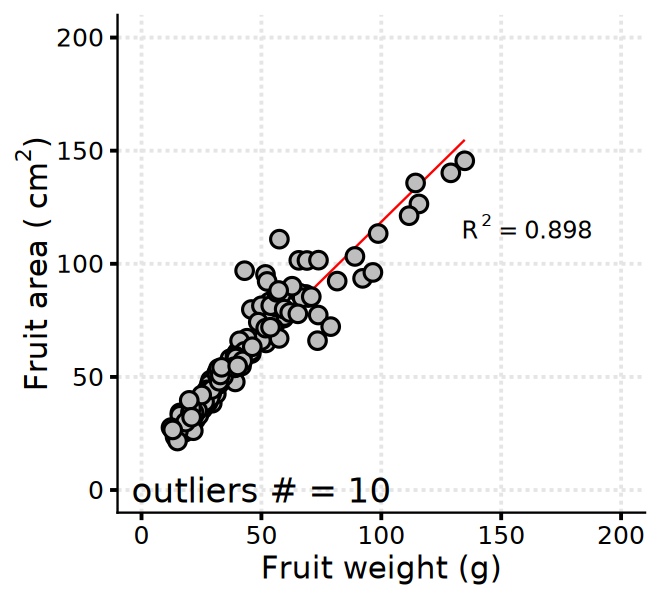

In [27]:
Fig3= ggplot (df2, aes (x=weight_g, y=area_cm2)) +
  geom_smooth(method=lm, level=0.95, se=FALSE, linetype=1, 
  linewidth=0.5, color="red", formula=y~x) +
  geom_point(aes(fill=category, shape=category), 
  stroke=1, size=4) +
  
  # R-squared
  stat_poly_eq(aes(label=paste(..rr.label.., sep= "~~~")),
               label.x=0.9, label.y=0.6, rr.digits=3,
               formula=y ~ x, parse=TRUE, size=5) +
  
  scale_fill_manual(values= c ("grey","red")) + 
  scale_shape_manual(values= c (21,21)) +
  annotate("text", label=paste("outliers # =", 
  sum(df1$category=="outlier")),
  x=50, y=0, size=7, color="black") +
  scale_x_continuous(breaks = seq(0,200,50), limits = c(0,200)) +
  scale_y_continuous(breaks = seq(0,200,50), limits = c(0,200)) +
  labs(x="Fruit weight (g)", y=bquote("Fruit area ("~cm^2*")")) +
  theme_classic(base_size=18, base_family="sans")+
  theme(legend.position="none",
        legend.title=element_text(size=11),
        legend.key.size=unit(0.2,'cm'),
        legend.key=element_rect(color=alpha("white",.05), 
                                fill=alpha("white",.05)),
        legend.text=element_text(size=11),
        legend.background= element_rect(fill=alpha("white",.05)),
        panel.grid.major= element_line(color="grey90", linetype="dashed"),
        axis.line=element_line(linewidth=0.5, colour="black"))

options(repr.plot.width=5.5, repr.plot.height=5)
print(Fig3)

ggsave("Fig3.png", plot= Fig3, width=5.5, height= 5, dpi= 300)

In [28]:
model= lm(area_cm2 ~ weight_g, data= df2)
summary (model)


Call:
lm(formula = area_cm2 ~ weight_g, data = df2)

Residuals:
    Min      1Q  Median      3Q     Max 
-24.843  -4.108  -1.045   2.632  37.734 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 14.45154    1.38810   10.41   <2e-16 ***
weight_g     1.04103    0.02908   35.80   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 8.559 on 145 degrees of freedom
Multiple R-squared:  0.8984,	Adjusted R-squared:  0.8977 
F-statistic:  1282 on 1 and 145 DF,  p-value: < 2.2e-16


# The datacooks() function works even with missing values

In [35]:
df= data.frame(Treatment= rep(c("N1", "N0"), c(40L, 31L)),Block= rep(c("I", "II", "III", "IV", "I", "II", "IV", "I", "II", "III", "IV", "I", "II", "III", "IV", "I", "II", "III",  "IV", "II", "III", "IV", "II", "III", "II", "III", "IV", "I", "II", "III", "I", "II", "III", "IV"), c(3L, 3L, 2L, 1L, 3L, 1L, 1L, 1L, 1L, 2L, 1L, 5L, 3L, 4L, 1L, 2L, 1L, 2L, 3L, 1L, 4L, 2L,  1L, 1L, 2L, 2L, 1L, 3L, 3L, 2L, 4L, 2L, 1L, 2L)), FreshWeight= c(9, 5, 17, 5, 14, 3, 8, 14, 3, 3, 3, 5, 4, 5, 6, 11, 3, 2, 18, 3, 6, 2, 5, 2, 2, 3, 15, 4, 11, 1, 1, 27, 9, 7, 13, 
  3, 12, 2, 11, 5, 11, 6, 0.1, 9, 11, 3, 2, 6, 3, 12, 12, 3, 2, 9, 2, 9, 1, 10, 3, 2, 5, 2, 4, 5, 3, 12, 7, 11, 2, 1, 7), DryWeight= c(0.9, 0.9, 3.9, 1, 2.6, NA, 1.1, 2.6, 0.5, 0.5, NA, 1.1, 0.6, 0.7, 1.3, 2, 0.5, 0.5, 3.5, 0.7, NA, 0.2, 1, 0.1, 0.4, 1, 2.4, 0.4, 1.8, NA, 0.2, 4.6, 1.4, 1.1, 2, 0.4, 1, 0.3, 1.9, 0.9, 1.3, 0.9, 0.015, 1.2, 1.8, 0.3, 0.39, 1, 0.3, 2, 2.2, 0.5, 0.4, 1.7, 0.3, 1.5, 0.1, 1.6, 0.4, 0.4, 0.9, 0.4, 0.4, 0.8, 0.4, 2, 1.4, 1.7, 0.4, 0, 1.2))

In [40]:
set.seed(100)
print(df[sample(nrow(df),5),])

   Treatment Block FreshWeight DryWeight
23        N1     I           5       1.0
70        N0    IV           1       0.0
4         N1    II           5       1.0
55        N0     I           2       0.3
7         N1   III           8       1.1


In [36]:
colSums(is.na(df))

Treatment       Block FreshWeight   DryWeight 
          0           0           0           4

In [37]:
model=lm(DryWeight~ FreshWeight, data=df)
summary(model)


Call:
lm(formula = DryWeight ~ FreshWeight, data = df)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.03916 -0.09502  0.00351  0.10351  0.98951 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -0.052043   0.052737  -0.987    0.327    
FreshWeight  0.174267   0.006332  27.523   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.2614 on 65 degrees of freedom
  (4 observations deleted due to missingness)
Multiple R-squared:  0.921,	Adjusted R-squared:  0.9198 
F-statistic: 757.5 on 1 and 65 DF,  p-value: < 2.2e-16


In [38]:
df1= datacooks(model, threshold= 4, clean= FALSE)

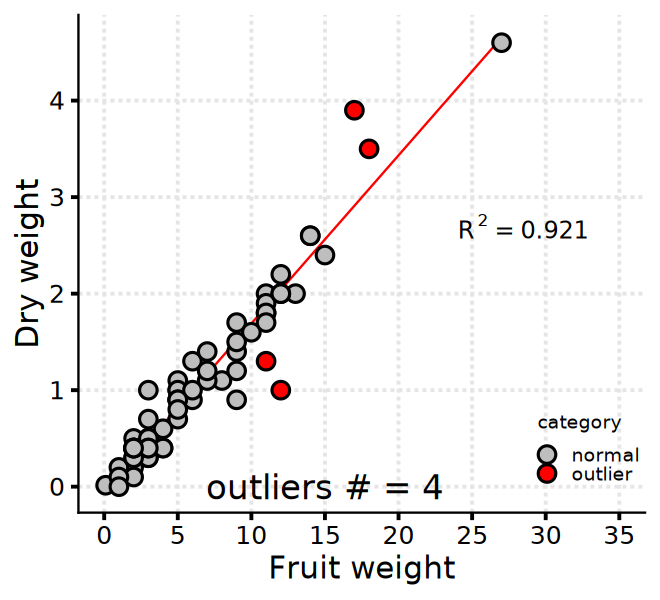

In [53]:
if(!require(ggplot2)) install.packages("ggplot2")
if(!require(ggpmisc)) install.packages("ggpmisc")
library(ggplot2)
library(ggpmisc)

Fig2= ggplot(df1, aes(x=FreshWeight, y=DryWeight)) +
  geom_smooth(method=lm, level=0.95, se=FALSE, 
  linetype=1, linewidth=0.5, color="red", formula=y~x) +
  geom_point(aes(fill=category, shape=category), 
  stroke=1, size=4) +
  # R-squared
  stat_poly_eq(aes(label=paste(..rr.label.., sep= "~~~")),
               label.x=0.9, label.y=0.6, rr.digits=3,
               formula=y ~ x, parse=TRUE, size=5) +

  scale_fill_manual(values= c ("grey","red")) + 
  scale_shape_manual(values= c (21,21)) +

  annotate("text", label=paste("outliers # =", 
  sum(df1$category=="outlier")),
  x=15, y=0, size=7, color="black") +

  scale_x_continuous(breaks = seq(0,35,5), limits = c(0,35)) +
  #scale_y_continuous(breaks = seq(0,7,1), limits = c(0,7)) +
  labs(x="Fruit weight", y="Dry weight") +
  theme_classic(base_size=18, base_family="sans")+
  theme(legend.position=c(0.89,0.13),
        legend.title=element_text(size=11),
        legend.key.size=unit(0.2,'cm'),
        legend.key=element_rect(color=alpha("white",.05), 
        fill=alpha("white",.05)),
        legend.text=element_text(size=11),
        legend.background= element_rect(fill=alpha("white",.05)),
        panel.grid.major= element_line(color="grey90", linetype="dashed"),
        axis.line=element_line(linewidth=0.5, colour="black"))

options(repr.plot.width=5.5, repr.plot.height=5)
print(Fig2)

ggsave("Fig2.png", plot= Fig2, width=5.5, height= 5, dpi= 300)